### Célula 1: Configuração do Ambiente e Arquitetura Modular
Importação das bibliotecas base e carregamento dos nossos módulos internos (`core` e `utils`). A modularização mantém o notebook focado apenas na orquestração e análise visual da estratégia.

In [61]:
# Core libraries
import importlib
import numpy as np
from itertools import combinations

# Utilities
import warnings
warnings.filterwarnings("ignore")

# Variables
import config as cfg
importlib.reload(cfg)

import core.analyse as an
importlib.reload(an)

import core.dataset as dt
importlib.reload(dt)

import core.models as model
importlib.reload(model)

import core.backtest as backT
importlib.reload(backT)

import utils.metrics as metric
importlib.reload(metric)

import utils.io as io
importlib.reload(io)

<module 'utils.io' from 'c:\\Users\\Asus\\Desktop\\Git\\master-projects\\financial-market-analysis\\src\\utils\\io.py'>

### Célula 2: Extração de Dados de Mercado
Recolha das cotações históricas diárias (via `yfinance` ou API equivalente) para o universo de ativos (*Tickers*) previamente definido no ficheiro de configuração.

In [ ]:
if cfg.DOWNLOAD_STOCKS is True:
    prices = io.get_stock_data(cfg.TICKERS)
    print("All data downloaded.")

### Célula 3: Divisão Temporal (Look-Ahead Bias Prevention)
Separação estrita dos dados em dois períodos: Formação (2016-2023) para treino dos modelos e descoberta de relações estatísticas, e Trading/Testing (2024-2026) para simulação num ambiente cego (*Out-of-Sample*).

In [47]:
# Prevenir Look-Ahead Bias
# Usamos 2016-2023 para encontrar a estrutura dos pares (Formation)
# Usamos 2024-2026 para os Agentes operarem (Trading/Testing)
prices = prices.dropna()
prices_formation = prices.loc[cfg.TRAIN_START:cfg.TRAIN_END]
prices_trading = prices.loc[cfg.TEST_START:cfg.TEST_END]

print(f"Formação: {cfg.TRAIN_START} a {cfg.TRAIN_END} ({prices_formation.shape[0]} dias)")
print(f"Teste: {cfg.TEST_START} a {cfg.TEST_END} ({prices_trading.shape[0]} dias)")

Formação: 2010-01-01 a 2015-12-31 (1361 dias)
Teste: 2021-01-01 a 2024-05-01 (837 dias)


### Célula 4: Cálculo de Retornos (Período de Formação)
Cálculo dos retornos percentuais diários aplicados exclusivamente aos dados de formação, garantindo que o motor de descoberta não tem acesso a volatilidade futura.

In [48]:
# Calculamos os retornos APENAS nos dados de Formação
returns_formation = prices_formation.pct_change().dropna()
returns_formation.head()

Ticker,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,WSM,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
Date,,,,,,,,,,,,,,,,,,,,,
2010-08-09,0.037939,0.006382,0.006130,0.010831,0.007449,0.009921,0.010607,0.014910,0.004812,0.009037,...,0.028561,0.013897,0.009062,0.013978,0.024476,0.006781,0.007746,0.007790,0.000185,0.006614
2010-08-10,-0.012073,-0.008940,0.011596,-0.001134,-0.002465,-0.011856,-0.019679,0.000327,-0.009816,-0.014812,...,-0.021441,-0.019581,-0.012508,-0.009765,-0.022137,0.006287,-0.008327,-0.007027,-0.001667,-0.015440
2010-08-11,-0.042091,-0.035542,-0.020983,-0.022463,-0.011860,-0.031539,-0.026765,-0.026110,-0.023210,-0.023776,...,-0.041667,-0.025392,-0.019163,-0.051044,-0.046478,-0.011602,-0.017889,-0.029252,-0.035065,-0.030364
2010-08-12,-0.024451,0.006395,0.000000,0.000387,-0.013254,-0.006018,-0.029563,0.025469,-0.009901,-0.016834,...,0.008620,0.010831,-0.008278,0.006112,-0.002982,0.005869,-0.002650,-0.003645,-0.000192,-0.010323
2010-08-13,-0.006539,-0.010684,-0.006549,-0.005420,-0.015459,-0.002493,-0.005668,-0.017974,-0.005250,0.024408,...,-0.008547,-0.028091,-0.001001,-0.006075,0.003796,0.006284,-0.005313,-0.003659,-0.010769,-0.011474


### Célula 5: Descoberta de Pares (RMT e HDBSCAN)
Filtragem matemática do ruído do mercado usando a Teoria das Matrizes Aleatórias (RMT) de Marchenko-Pastur, seguida da aplicação do algoritmo HDBSCAN para encontrar *clusters* de ações estruturalmente correlacionadas.

Total de ações (N): 428 | Total de dias (T): 1360
Limite de Ruído Marchenko-Pastur (lambda_max): 2.4367
-> Componentes Principais Retidos (Sinal Puro): 11


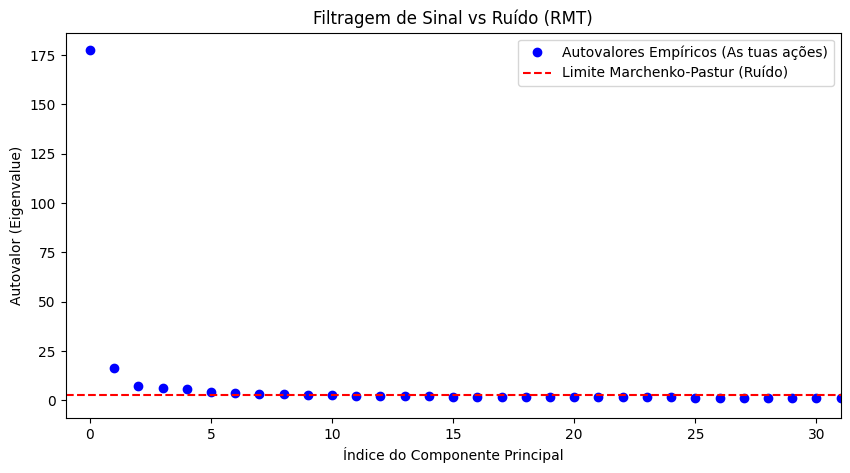

Resumo do HDBSCAN:
-> 78 clusters estruturais encontrados.
-> 146 ações rejeitadas como ruído.



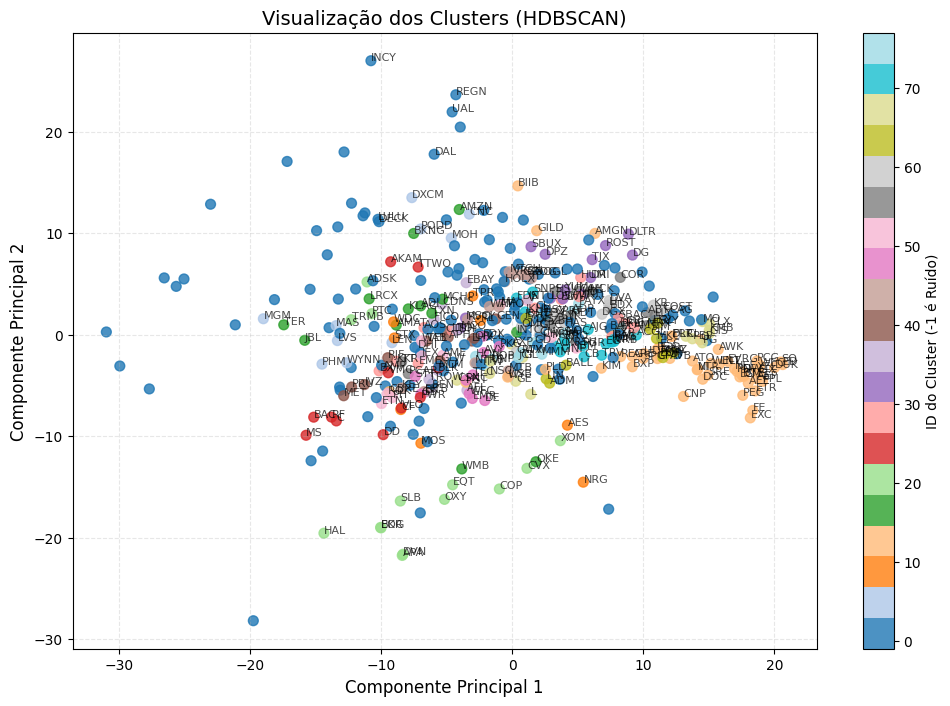


Pares Candidatos Extraídos: 859


In [49]:
# 1. Filtro de Ruído Institucional (Marchenko-Pastur)
X_pca_sota = an.calculate_RMT(returns_formation)

# 2. Aplicar o HDBSCAN (Ajusta-se automaticamente às densidades)
pairs_grouped, clusters_dict = an.RMT_clustering_hdbscan(X_pca_sota, returns_formation)

# 3. Extrair todas as combinações (2 a 2) dentro dos clusters encontrados
candidate_pairs = []
for cluster_list in clusters_dict.values():
    if len(cluster_list) > 1:
        for combo in combinations(cluster_list, 2):
            candidate_pairs.append(list(combo))

print(f"\nPares Candidatos Extraídos: {len(candidate_pairs)}")

### Célula 6: Validação Estrutural (Cointegração e Elasticidade)
Filtra as combinações candidatas garantindo estacionariedade forte (Teste ADF) e velocidade de reversão rápida (Expoente de Hurst < 0.4). O *Hedge Ratio* (Beta) de cada par é calculado recorrendo ao método simétrico de *Total Least Squares* (TLS).

In [50]:
print(f"A testar {len(candidate_pairs)} pares candidatos (TLS + ADF + Hurst)...")
valid_pairs_df, spreads_dict = an.validate_pairs(candidate_pairs, prices_formation, prices)

print(f"-> Sobreviveram {len(valid_pairs_df)} pares institucionais!")
display(valid_pairs_df.head(10))

A testar 859 pares candidatos (TLS + ADF + Hurst)...
-> Sobreviveram 17 pares institucionais!


,ativo_y,ativo_x,beta_tls,adf_p_value,hurst
15,KIM,REG,0.936432,0.000044,0.364295
1,AWK,CMS,1.093958,0.002380,0.373446
12,BLK,TROW,1.737656,0.019481,0.379191
5,DTE,ES,1.220758,0.012743,0.382434
3,CMS,DTE,1.062380,0.035582,0.384457
13,AMT,SBAC,0.595871,0.025995,0.384557
6,DTE,LNT,1.089983,0.028850,0.385998
10,EVRG,XEL,1.149765,0.037435,0.386337
2,AWK,LNT,1.268418,0.005420,0.390339
14,AVB,UDR,0.953342,0.027536,0.394035


### Célula 7: Feature Engineering e Tripla Barreira
Modelação da física diária do *spread*. Calcula métricas como a ECDF (anomalias de preço) e os parâmetros de *Ornstein-Uhlenbeck* (velocidade, centro de gravidade e meia-vida). Por fim, aplica o Método da Tripla Barreira para rotular os sinais históricos como Sucesso (1) ou Fracasso (0) para treino supervisionado.

In [51]:
global_meta_dataset = dt.build_global_dataset(
    valid_pairs_df, spreads_dict, cfg.TRAIN_END, 
    cfg.WINDOW, cfg.LOWER_PERCENTILE, cfg.UPPER_PERCENTILE, cfg.SL_MULTIPLIER
)

# CRIAR A PASTA DE RESULTADOS AQUI
save_dir = io.setup_results_dir(cfg)

# Guardar o dataset base para efeitos de auditoria
global_meta_dataset.to_csv(f"{save_dir}/dataset_treino.csv")

print(f"\n--- DATASET GLOBAL CONSTRUÍDO ---")
print(f"Total Trades Históricos: {len(global_meta_dataset)}")
print(f"Win-Rate Agente Base: {(global_meta_dataset['target'].mean() * 100):.2f}%")


100%|██████████| 17/17 [00:37<00:00,  2.18s/it]

-> Diretório de resultados criado: ../results/Train_2010-01-01_to_2015-12-31__Test_2021-01-01_to_2024-05-01

--- DATASET GLOBAL CONSTRUÍDO ---
Total Trades Históricos: 544
Win-Rate Agente Base: 24.45%


### Célula 8: O Meta-Agente (Treino SOTA)
Treino do modelo preditivo de *Machine Learning* (Ensemble). Utiliza *TimeSeriesSplit* com *Embargo* (Purged K-Fold) para prevenir o vazamento de informação temporal (*Data Leakage*), extraindo a importância que o modelo dá a cada variável.

In [52]:
# 1. Treino do Modelo Global
if cfg.TRAIN_MODELS is True:
    meta_agent_global, cv_scores, importances = model.train_meta_agent(global_meta_dataset)

    # 2. Treino dos Modelos Específicos
    specific_agents_dict = model.train_specific_agents(global_meta_dataset)

print("=== VALIDAÇÃO CRUZADA GLOBAL (Meta-Agente) ===")
print(f"Accuracy Preditiva: {cv_scores.mean():.2f} (+/- {cv_scores.std():.2f})")
print("\n-> Importância das Variáveis:")
print(importances)

=== VALIDAÇÃO CRUZADA GLOBAL (Meta-Agente) ===
Accuracy Preditiva: 0.63 (+/- 0.04)

-> Importância das Variáveis:
theta         0.349809
half_life     0.347062
volatility    0.227473
ecdf          0.062290
side          0.013367
dtype: float64


### Célula 9: Análise de Risco (Threshold Tuning)
Ajuste interativo do limiar de exigência probabilística do Meta-Agente. Permite ao analista quantitativo decidir o ponto ótimo de equilíbrio entre o número de trades gerados (*Recall*) e a fiabilidade estatística (*Precision*).

In [53]:
# 1. Prever as probabilidades no dataset global usando o Modelo Global
X_global = global_meta_dataset[['ecdf', 'theta', 'half_life', 'volatility', 'side']]
global_meta_dataset['Prob_Sucesso_Global'] = meta_agent_global.predict_proba(X_global)[:, 1]

probs_sucesso = global_meta_dataset['Prob_Sucesso_Global']
y_real = global_meta_dataset['target']

print("=== ANÁLISE DE CONFIANÇA DO PORTÃO 2 (MODELO GLOBAL) ===")
df_thresholds = metric.tune_threshold(probs_sucesso, y_real, thresholds=np.arange(0.5, 0.9, 0.05))
display(df_thresholds)

# Gravar a análise de limiares e as importâncias na nossa pasta de resultados
df_thresholds.to_csv(f"{save_dir}/threshold_analysis_global.csv", index=False)
importances.to_csv(f"{save_dir}/feature_importances_global.csv")

# Gravar a autorização no dataset
global_meta_dataset['Trade_Autorizado'] = (global_meta_dataset['Prob_Sucesso_Global'] >= cfg.LIMIAR_FINAL).astype(int)

print(f"\n-> Usando o Limiar de {cfg.LIMIAR_FINAL*100}%, o bot autorizou {global_meta_dataset['Trade_Autorizado'].sum()} trades durante o período de formação.")

# Atualizar o ficheiro do dataset de treino com as novas colunas de probabilidade
global_meta_dataset.to_csv(f"{save_dir}/dataset_treino.csv")

=== ANÁLISE DE CONFIANÇA DO PORTÃO 2 (MODELO GLOBAL) ===


,Limiar (%),Trades Aprovados,Precision (Win-Rate),Recall (Oportunidades)
0,50%,167,42.5%,53.4%
1,55%,108,49.1%,39.8%
2,60%,77,50.6%,29.3%
3,65%,48,66.7%,24.1%
4,70%,23,87.0%,15.0%
5,75%,8,100.0%,6.0%
6,80%,0,0.0%,0.0%
7,85%,0,0.0%,0.0%



-> Usando o Limiar de 60.0%, o bot autorizou 77 trades durante o período de formação.


### Célula 10: Motor de Backtest Institucional (Out-of-Sample)
Simulação *Walk-Forward* no período 2024-2026. O motor avalia os sinais do Agente Base, requer autorização ao Meta-Agente, calcula a exposição usando o Critério de Kelly com alavancagem de 3x, e fecha posições dinamicamente através da Tripla Barreira.

In [54]:
print("=== BACKTEST 1: MODELO GLOBAL ===")
trades_global = backT.run_oos_backtest(
    valid_pairs_df=valid_pairs_df, spreads_dict=spreads_dict, 
    models_dict={'global': meta_agent_global}, mode='global',
    test_start=cfg.TEST_START, test_end=cfg.TEST_END,
    window=cfg.WINDOW, lower_pct=cfg.LOWER_PERCENTILE, upper_pct=cfg.UPPER_PERCENTILE, 
    sl_mult=cfg.SL_MULTIPLIER, limiar_final=cfg.LIMIAR_FINAL, alavancagem_fundo=cfg.ALAVANCAGEM_FUNDO
)

if not trades_global.empty:
    trades_global.to_csv(f"{save_dir}/trades_global.csv", index=False)

print("\n=== BACKTEST 2: MODELOS ESPECÍFICOS ===")
trades_specific = backT.run_oos_backtest(
    valid_pairs_df=valid_pairs_df, spreads_dict=spreads_dict, 
    models_dict=specific_agents_dict, mode='specific',
    test_start=cfg.TEST_START, test_end=cfg.TEST_END,
    window=cfg.WINDOW, lower_pct=cfg.LOWER_PERCENTILE, upper_pct=cfg.UPPER_PERCENTILE, 
    sl_mult=cfg.SL_MULTIPLIER, limiar_final=cfg.LIMIAR_FINAL, alavancagem_fundo=cfg.ALAVANCAGEM_FUNDO
)

if not trades_specific.empty:
    trades_specific.to_csv(f"{save_dir}/trades_specific.csv", index=False)

print("\n=== BACKTEST 3: CROSS-TESTING (TRANSFER LEARNING) ===")
trades_cross = backT.run_oos_backtest(
    valid_pairs_df=valid_pairs_df, spreads_dict=spreads_dict, 
    models_dict=specific_agents_dict, mode='cross_testing',
    test_start=cfg.TEST_START, test_end=cfg.TEST_END,
    window=cfg.WINDOW, lower_pct=cfg.LOWER_PERCENTILE, upper_pct=cfg.UPPER_PERCENTILE, 
    sl_mult=cfg.SL_MULTIPLIER, limiar_final=cfg.LIMIAR_FINAL, alavancagem_fundo=cfg.ALAVANCAGEM_FUNDO
)

if not trades_cross.empty:
    trades_cross.to_csv(f"{save_dir}/trades_cross_testing.csv", index=False)
    
    # Se quiseres ver rapidamente as estatísticas do Cross-Testing:
    print(f"\nNo modo Cross-Testing executou {len(trades_cross)} trades.")
    win_rate_cross = len(trades_cross[trades_cross['exit_reason'] == 'Take-Profit']) / len(trades_cross) * 100
    print(f"Win-Rate Cross-Testing: {win_rate_cross:.2f}%")



=== BACKTEST 1: MODELO GLOBAL ===


OOS Backtest (GLOBAL): 100%|██████████| 17/17 [01:55<00:00,  6.80s/it]



=== BACKTEST 2: MODELOS ESPECÍFICOS ===


OOS Backtest (SPECIFIC): 100%|██████████| 17/17 [01:52<00:00,  6.63s/it]



=== BACKTEST 3: CROSS-TESTING (TRANSFER LEARNING) ===


OOS Backtest (CROSS_TESTING): 100%|██████████| 17/17 [01:54<00:00,  6.72s/it]


No modo Cross-Testing executou 113 trades.
Win-Rate Cross-Testing: 13.27%


### Célula 11: Relatório de Performance (Quant Tearsheet)
Avaliação final da rentabilidade e risco da estratégia. Compila o registo de operações num relatório detalhado (Win-Rate, Risco/Recompensa, taxas de paragem) e gera visualizações da Curva de Capital (*Equity Curve*) e respetivo *Drawdown* máximo histórico.


=== ANÁLISE COMPARATIVA SOTA (TRÊS ABORDAGENS) ===

=== RESUMO DE PERFORMANCE (OUT-OF-SAMPLE) ===
                    Modelo Global  Modelos Específicos  Cross-Testing
Total Trades               139.00                85.00         113.00
Win-Rate (%)                17.99                 9.41          13.27
Stop-Loss Rate (%)          18.71                15.29          23.01
Time-Stop Rate (%)          63.31                75.29          63.72
Lucro Médio (%)              0.60                 0.51           0.46
Perda Média (%)             -0.71                -0.45          -0.61
Risco/Recompensa             0.86                 1.13           0.75
Retorno Total (%)            5.01                -0.16          -0.94
Max Drawdown (%)            -9.83                -6.03          -5.49
-> Relatórios de métricas salvos em: ../results/Train_2010-01-01_to_2015-12-31__Test_2021-01-01_to_2024-05-01/performance_metrics.csv (e .txt)


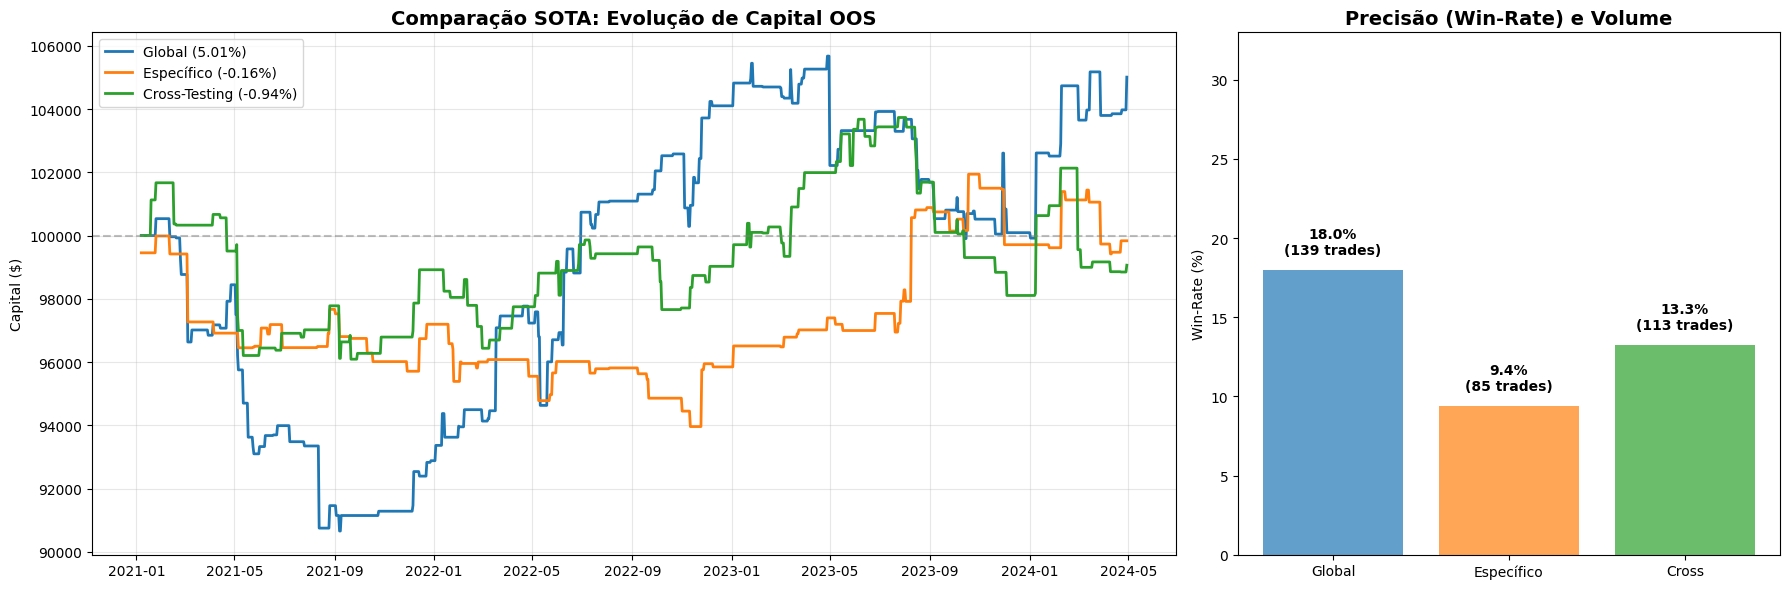

-> Gráfico comparativo SOTA salvo em: ../results/Train_2010-01-01_to_2015-12-31__Test_2021-01-01_to_2024-05-01/comparison_sota.png

=== A GERAR GRÁFICOS INDIVIDUAIS DE ENTRADA/SAÍDA ===
-> 17 gráficos de pares detalhados guardados na pasta: ../results/Train_2010-01-01_to_2015-12-31__Test_2021-01-01_to_2024-05-01/graficos_trades_Global/
-> 12 gráficos de pares detalhados guardados na pasta: ../results/Train_2010-01-01_to_2015-12-31__Test_2021-01-01_to_2024-05-01/graficos_trades_Especifico/
-> 14 gráficos de pares detalhados guardados na pasta: ../results/Train_2010-01-01_to_2015-12-31__Test_2021-01-01_to_2024-05-01/graficos_trades_Cross/


In [55]:
# Célula 11
print("\n=== ANÁLISE COMPARATIVA SOTA (TRÊS ABORDAGENS) ===")
# Passamos os 3 DataFrames
io.compare_strategies(trades_global, trades_specific, trades_cross, cfg.CAPITAL_INICIAL, save_dir)

print("\n=== A GERAR GRÁFICOS INDIVIDUAIS DE ENTRADA/SAÍDA ===")
io.generate_trade_plots(trades_global, spreads_dict, save_dir, model_name="Global")
io.generate_trade_plots(trades_specific, spreads_dict, save_dir, model_name="Especifico")
io.generate_trade_plots(trades_cross, spreads_dict, save_dir, model_name="Cross")